In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.express as px

%matplotlib inline
plt.style.use('default')


In [4]:
churn_data = pd.read_csv('data/churn.csv')
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# Подготавливаем датафрейм с количеством лояльных и ушедших клиентов
exited_df = pd.DataFrame(
    data = [
        ['Лояльные', churn_data[churn_data['Exited'] == 0]['RowNumber'].count()],
        ['Ушедшие', churn_data[churn_data['Exited'] == 1]['RowNumber'].count()]
    ],
    columns= ['Exited', 'Quantity'],
)

fig = px.pie(exited_df, values="Quantity", names='Exited', title='Соотношение ушедших и лояльных клиентов')
fig.show()

Комментарий: лояльных клиентов почти в 4 раза больше чем ушедших.

In [26]:
fig = px.histogram(churn_data[churn_data['Balance'] > 2500], x = 'Balance', title = 'Распределение баланса пользователей, у которых на счету больше 2 500 долларов')
fig.show()

Большинство клиентов имеют баланс от 96 до 140 тысяч. Очень мало клиентов имеют баланс менее 50 или более 200 тысяч. 

In [40]:
fig = px.histogram(churn_data, x = 'Balance', color= 'Exited', title = 'Распределение баланса клиента в разрезе признака оттока')
fig.show()

Среди лояльных клиентов многие имеют нулевой баланс, в остальном распределение примерно одинаковое.

In [43]:
fig = px.box(churn_data, x = 'Age', color= 'Exited', title = 'Распределение возраста в разрезе признака оттока')
fig.show()

Ушедшие клиенты имеют более старший возраст.

In [49]:
fig = px.scatter(churn_data, x = 'CreditScore', y = 'EstimatedSalary', color= 'Exited', log_y=True, 
                 title = 'Взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты')
fig.show()

Явной взаимосвязи между кредитным рейтингом клиента и его предполагаемой зарплатой не видно, однако заметно что все клиенты с рейтингом ниже 400 ушли.

In [70]:
result_data = churn_data.groupby(
    by='Gender',
    as_index=False
)[['Exited']].mean()

#fig = px.bar(churn_data[churn_data['Exited'] == 1], x = 'Gender', title = 'Кто чаще уходит, мужчины или женщины')
fig = px.bar(result_data, x = 'Gender', y = 'Exited', title = 'Кто чаще уходит, мужчины или женщины?')
fig.show()

In [82]:
result_data = churn_data.groupby(
    by='NumOfProducts',
    as_index=False
)[['Exited']].mean()

fig = px.bar(result_data, y = 'Exited', x = 'NumOfProducts', title = 'Как отток клиентов зависит от числа приобретённых у банка услуг?')
fig.show()

Из диаграммы видно что клиенты имеющие 1 или 2 услуги банка остаются лояльными, клиенты имеющие 3 услуги в большинстве случаев уходят, а люди имеющие 4 услуги ушли все.

In [90]:
result_data = churn_data.groupby(
    by='IsActiveMember',
    as_index=False
)[['Exited']].mean()

fig = px.bar(result_data, y = 'Exited', x = 'IsActiveMember', title = 'Как влияет наличие статуса активного клиента на отток клиентов?')
fig.show()

Доля лояльных клиентов среди активных выше чем среди неактивных.

In [93]:
result_data = churn_data.groupby(
    by='Geography',
    as_index=False
)[['Exited']].mean()

fig = px.choropleth(
    data_frame=result_data,
    locations="Geography",
    locationmode = "country names",
    color="Exited",
    range_color=[0, 1],
    title='В какой стране доля ушедших клиентов больше?',
    width=800,
    height=500,
    color_continuous_scale='Reds'
)

#отображаем график
fig.show()

C:\Users\Максим\AppData\Local\Temp\ipykernel_19744\279585398.py:6: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


Больше всего клиентов ушли в Германии

In [5]:
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"
    
churn_data['CreditScore_cat'] = churn_data['CreditScore'].apply(get_credit_score_cat)

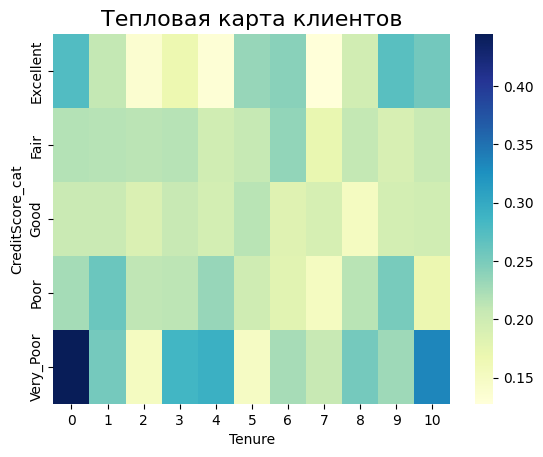

In [6]:
pivot = churn_data.pivot_table(
 values='Exited',
 columns='Tenure',
 index='CreditScore_cat',
)
 
heatmap = sns.heatmap(data=pivot, cmap='YlGnBu')
heatmap.set_title('Тепловая карта клиентов', fontsize=16);

Чаще всего уходят клиенты с очень плохим кредитным рейтингом пользующиеся услугами банка менее одного года, а так же 3, 4 и 10 лет.